<a href="https://colab.research.google.com/drive/1LPNTf8PixDhSJs8Vz33-9MSMVm9xBcgD" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Homework Assignment: Optimizing the Classification Threshold in Logistic Regression**

-------------------------------

In this assignment, you will explore the concept of **classification thresholds** in **Logistic Regression** and investigate whether the commonly used threshold of **0.5** is always the optimal choice. To complete this assignment, you will need to conduct **additional reading** on **ROC curves** and the **AUC metric**, beyond the materials covered in class.

This exercise focuses on the **importance of threshold selection** and how it impacts model performance based on different evaluation criteria.



## **The Objective**

**Is a 0.5 threshold always the best choice in Logistic Regression?**

- Analyze if the standard threshold of **0.5** always yields the most desirable results in various scenarios.
- Investigate alternative thresholds and how they can improve model performance depending on the problem context.



## **Helper Questions**

1. **Would a different threshold yield better results?**  
   - How does shifting the threshold affect the **trade-off between sensitivity and specificity**?

2. **How do you define "better" results?**  
   - Is **higher specificity** more valuable than **higher sensitivity** in certain contexts? Or maybe the other way around?
   - Does the **best threshold** depend on the task? (discuss cases like *disease detection* vs. *spam filtering*)

3. **How does a ROC curve help in this process?**  
   - Learn how to use a **ROC curve** to visualize the trade-off between **True Positive Rate (Sensitivity)** and **False Positive Rate (1 - Specificity)**.

4. **How do you select the optimal threshold using the ROC curve?**  
   - Discuss strategies to select a threshold depending on the specific task at hand and the acceptable **trade-off between sensitivity and specificity**.

5. **What is the AUC metric and how is it useful?**  
   - Define **AUC (Area Under the Curve)** and discuss its role in evaluating the overall performance of a classifier.



## **Tasks & Deliverables**

1. **Colab Notebook**
   - Select a suitable classification 2-class dataset.
   - Divide the dataset into three parts: **train**, **validation**, and **test**.
   - Train the **Logistic Regression** model on the **training** set.
   - Use the **validation** set to:
     - Plot the **ROC curve**.
     - Calculate the **AUC**.
     - Determine the **optimal threshold** using the ROC curve for your dataset.
   - Apply the selected threshold to the **test** set to evaluate final model performance using metrics like:
     - **Accuracy**
     - **Precision & Recall**
     - **F1-Score**
     - **Specificity & Sensitivity**

2. **Answer the Questions:**
   - Use markdown cells to provide explanations.
   - Answer all helper questions with supporting evidence from your plots and results.

3. **Visualizations:**
   - **ROC curve** based on the **validation** set with threshold points marked.
   - Highlight the **optimal threshold** on the ROC curve.

4. **Publish on GitHub**  
   - Place the Colab notebook in your **GitHub repository** for this course.
   - In your repository’s **README**, add a **link** to the notebook and also include an **“Open in Colab”** badge at the top of the notebook so it can be launched directly from GitHub.




In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

# Generate synthetic data based on the ideal logistic model
np.random.seed(42)

# Define coefficients for the logistic model
beta_0 = -1  # Intercept
beta_1 = 2   # Slope

# Generate the feature values (X)
sample_size = 100000
X = np.linspace(-3, 3, sample_size).reshape(-1, 1)

# Calculate probabilities using the logistic function
logit = beta_0 + beta_1 * X.flatten()
probabilities = 1 / (1 + np.exp(-logit))

# Sample 0-1 values based on the probabilities
y = np.random.binomial(1, probabilities)

X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.4, random_state=42)
X_valid, X_test, y_valid, y_test = train_test_split(X_valid, y_valid, test_size=0.5, random_state=42)

# Fit Logistic Regression
logistic_model = LogisticRegression()
logistic_model.fit(X_train, y_train)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


Optymalny próg (Youden):0.39828083817837484


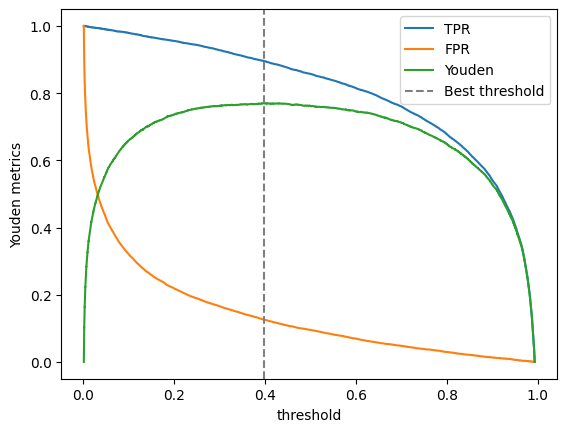

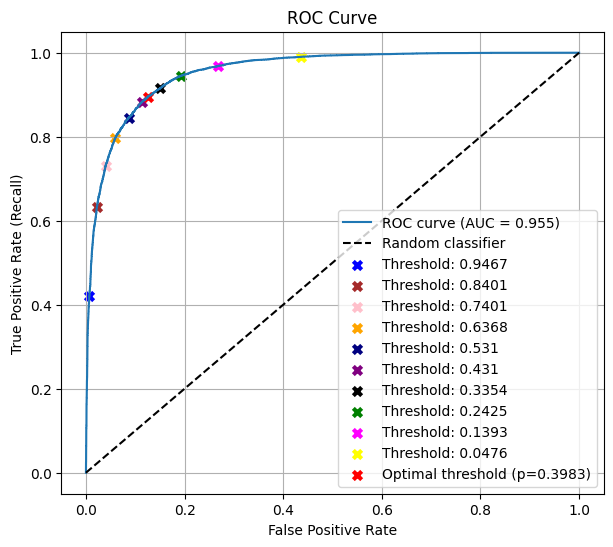

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score

y_valid_proba = logistic_model.predict_proba(X_valid)[:, 1]
# Compute ROC curve values
fpr, tpr, thresholds = roc_curve(y_valid, y_valid_proba)

# 4. Compute AUC
auc = roc_auc_score(y_valid, y_valid_proba)

youden = tpr - fpr
best_threshold = thresholds[youden.argmax()]
print(f"Optymalny próg (Youden):{best_threshold}")

plt.plot(thresholds, tpr, label="TPR")
plt.plot(thresholds, fpr, label="FPR")
plt.plot(thresholds, youden, label="Youden")
plt.axvline(x=best_threshold, linestyle="--", color="gray", label=f"Best threshold")
plt.xlabel("threshold")
plt.ylabel("Youden metrics")
plt.legend()
plt.show()


# 5. Plot ROC curve
colors = ["blue", "brown", "pink", "orange", "navy", "purple", "black", "green", "magenta", "yellow"]
sel_prob = thresholds[[thresholds.size//20*(2*i+1)  for i in range(10)]]
sel_fpr = fpr[[thresholds.size//20*(2*i+1)  for i in range(10)]]
sel_tpr = tpr[[thresholds.size//20*(2*i+1)  for i in range(10)]]

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {auc:.3f})")
plt.plot([0, 1], [0, 1], 'k--', label="Random classifier")
for i in range(sel_prob.size):
    plt.scatter(sel_fpr[i], sel_tpr[i], c=colors[i], marker="x", linewidths=3, label=f"Threshold: {sel_prob[i]:.4}")
plt.scatter(fpr[youden.argmax()], tpr[youden.argmax()], marker="x", linewidths=3, color="red", label=f"Optimal threshold (p={best_threshold:.4})")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Wybrany wcześniej próg
threshold = best_threshold   # 0.3983

# Predykcje prawdopodobieństw na zbiorze testowym
y_test_proba = logistic_model.predict_proba(X_test)[:, 1]

# Konwersja prawdopodobieństw na klasy przy użyciu wybranego progu
y_test_pred = (y_test_proba >= threshold).astype(int)

# Obliczenie podstawowych metryk
accuracy = accuracy_score(y_test, y_test_pred)
precision = precision_score(y_test, y_test_pred)
recall = recall_score(y_test, y_test_pred)   # sensitivity
f1 = f1_score(y_test, y_test_pred)

# Macierz pomyłek do obliczenia specificity
tn, fp, fn, tp = confusion_matrix(y_test, y_test_pred).ravel()


specificity = tn / (tn + fp)
sensitivity = recall   # alias

# Wyświetlenie wyników
print(f"Threshold value:\t{threshold:.4f}")
print(f"Accuracy (fraction of correctly classified samples):\t{accuracy:.4f}")
print(f"Precision (tp / (tp + fp)):\t{precision:.4f}")
print(f"Recall (TPR, tp / (tp + fn)):\t{recall:.4f}")
print(f"F1-score (2*tp / (2*tp+fp+fn)):\t{f1:.4f}")
print(f"Specificity (tn / (tn + fp)):\t{specificity:.4f}")
print(f"Sensitivity (tp / (tp + fn)):\t{sensitivity:.4f}")


Threshold value:	0.3983
Accuracy (fraction of correctly classified samples):	0.8823
Precision (tp / (tp + fp)):	0.8311
Recall (TPR, tp / (tp + fn)):	0.9019
F1-score (2*tp / (2*tp+fp+fn)):	0.8651
Specificity (tn / (tn + fp)):	0.8683
Sensitivity (tp / (tp + fn)):	0.9019


W zadaniu wykorzystałem zbiór danych, który był omawiany na zajęciach. Po wygenerowaniu danych podzieliłem je na zbiory treningowy, walidacyjny i testowy, a następnie wytrenowałem klasyczny model regresji logistycznej. Kolejnym krokiem była analiza jakości modelu przy użyciu krzywej ROC, która pozwala ocenić, jak zmieniają się wartości TPR (True Positive Rate) oraz FPR (False Positive Rate) w zależności od przyjętego progu klasyfikacji. Na podstawie predykcji prawdopodobieństw dla zbioru walidacyjnego wyznaczyłem krzywą ROC oraz obliczyłem wartość AUC. Otrzymany wynik, AUC = 0.955, wskazuje na dobrą jakość modelu i świadczy o tym, że klasyfikator skutecznie rozróżnia obie klasy w szerokim zakresie progów decyzyjnych.

Ponieważ w zadaniu nie znamy konkretnego kontekstu aplikacyjnego, nie można jednoznacznie stwierdzić, czy ważniejsza jest czułość, czy specyficzność modelu. Z tego powodu do wyboru optymalnego progu klasyfikacji zastosowałem statystykę Youdena, czyli różnicę TPR - FPR. Jest to uniwersalne kryterium, które pozwala znaleźć punkt zapewniający kompromis między wykrywaniem pozytywnych przypadków a ograniczaniem liczby fałszywych alarmów. W moim eksperymencie maksymalna wartość statystyki Youdena została osiągnięta dla progu około 0.3983. Oznacza to, że standardowy próg 0.5 nie jest w tym przypadku optymalny, a przesunięcie go w dół pozwala uzyskać lepszy balans pomiędzy czułością a specyficznością.

Wyniki uzyskane na zbiorze testowym wskazują, że model logistyczny działa dobrze przy zastosowaniu wybranego progu klasyfikacji równego około 0.3983. Osiągnięta dokładność na poziomie 0.8823 oznacza, że blisko 88% obserwacji zostało poprawnie sklasyfikowanych. Jednocześnie wysoka wartość czułości (sensitivity/recall), wynosząca ok.0.9019, pokazuje, że model skutecznie wykrywa przypadki pozytywne.

Precision na poziomie 0.8311 oznacza, że większość obserwacji zaklasyfikowanych jako pozytywne faktycznie należy do tej klasy, choć model dopuszcza pewną liczbę fałszywych alarmów. Jest to konsekwencja obniżenia progu względem wartości 0.5 - model staje się bardziej „wyczulony” na klasę pozytywną, co zwiększa recall kosztem częściowego spadku precision. F1‑score równy 0.8651 potwierdza, że kompromis między precision i recall jest zbalansowany.

Warto również zwrócić uwagę na specificity (0.8683), która pozostaje wysoka mimo obniżonego progu. Oznacza to, że model nadal skutecznie rozpoznaje klasę negatywną i nie generuje nadmiernej liczby fałszywych pozytywów. Sensitivity, będące równoważne recall, wynosi 0.9019, co potwierdza, że model radzi sobie z wykrywaniem przypadków pozytywnych.

1. **Would a different threshold yield better results?**  
   - How does shifting the threshold affect the **trade-off between sensitivity and specificity**?
   
Na podstawie przeprowadzonej analizy (powyższe dwa wykresy) można jednoznacznie stwierdzić, że zastosowanie innego progu klasyfikacji niż domyślne 0.5 może prowadzić do lepszych rezultatów, szczególnie jeżeli znamy dokłądny kontekst, w któym zamierzamy używać modelu (jak np. analiza wyników badań pacjentów lub selekcja spamu w skrzynce mailowej). Widać to wyraźnie zarówno na wykresie ROC, jak i na wykresie zależności TPR, FPR oraz statystyki Youdena od wartości progu. Zmiana progu klasyfikacji wpływa bezpośrednio na kompromis pomiędzy czułością (TPR) a specyficznością, czyli odwrotnością FPR. Przy bardzo niskich progach model klasyfikuje większość obserwacji jako pozytywne, co skutkuje wysoką czułością, ale jednocześnie dużą liczbą fałszywych alarmów (wysokim FPR). Wraz ze wzrostem progu czułość stopniowo maleje, natomiast specyficzność rośnie, ponieważ model staje się bardziej „ostrożny” w przypisywaniu klasy pozytywnej.

2. **How do you define "better" results?**  
   - Is **higher specificity** more valuable than **higher sensitivity** in certain contexts? Or maybe the other way around?
   - Does the **best threshold** depend on the task? (discuss cases like *disease detection* vs. *spam filtering*)

Definicja „lepszych” wyników w klasyfikacji zależy przede wszystkim od tego, jaki cel ma model i jakie konsekwencje niosą za sobą błędy klasyfikacji. Nie istnieje jeden uniwersalny próg, który byłby optymalny we wszystkich zastosowaniach, ponieważ wybór odpowiedniego thresholdu jest ściśle związany z kontekstem zadania. W niektórych sytuacjach bardziej pożądana jest wysoka czułość modelu, czyli zdolność do wykrywania jak największej liczby przypadków pozytywnych, nawet kosztem większej liczby fałszywych alarmów. W innych przypadkach kluczowa jest wysoka specyficzność, czyli minimalizowanie liczby błędnych klasyfikacji negatywnych jako pozytywne.

Dobrym przykładem jest diagnostyka chorób. W takim scenariuszu znacznie ważniejsza jest wysoka czułość, ponieważ pominięcie chorego pacjenta (fałszywy negatyw) może prowadzić do poważnych konsekwencji zdrowotnych. Z kolei fałszywy alarm, czyli błędne zaklasyfikowanie zdrowej osoby jako chorej, zwykle wiąże się jedynie z dodatkowymi badaniami i nie stanowi tak dużego zagrożenia. W takim przypadku optymalny próg klasyfikacji powinien być niższy, aby model był bardziej „wyczulony” na przypadki pozytywne.

Odwrotna sytuacja występuje w filtrach antyspamowych. Tutaj bardziej zależy nam na wysokiej specyficzności, ponieważ błędne oznaczenie ważnej wiadomości jako spamu (fałszywy pozytyw) może spowodować, że użytkownik nigdy jej nie zobaczy. Z kolei przepuszczenie kilku niechcianych wiadomości do skrzynki odbiorczej jest znacznie mniej dotkliwe — użytkownik może je po prostu usunąć. Dlatego w tym przypadku lepiej ustawić próg wyżej, aby model oznaczał jako spam tylko te wiadomości, które z bardzo dużym prawdopodobieństwem rzeczywiście są niechciane.

3. **How does a ROC curve help in this process?**  
   - Learn how to use a **ROC curve** to visualize the trade-off between **True Positive Rate (Sensitivity)** and **False Positive Rate (1 - Specificity)**.


4. **How do you select the optimal threshold using the ROC curve?**  
   - Discuss strategies to select a threshold depending on the specific task at hand and the acceptable **trade-off between sensitivity and specificity**.

Krzywa ROC odgrywa kluczową rolę w procesie wyboru odpowiedniego progu klasyfikacji, ponieważ pozwala w sposób wizualny i intuicyjny zrozumieć, jakie kombinacje czułości (TPR) i odsetka fałszywych alarmów (FPR) są możliwe do osiągnięcia przez dany model przy różnych wartościach thresholdu. Każdy punkt na krzywej ROC odpowiada innemu progowi decyzyjnemu, a więc innemu kompromisowi między tym, jak wiele przypadków pozytywnych zostanie wykrytych, a jak wiele przypadków negatywnych zostanie błędnie oznaczonych jako pozytywne.

Dzięki temu krzywa ROC pozwala zobaczyć pełne spektrum zachowań modelu — od bardzo wysokiej czułości przy niskich progach, po wysoką specyficzność przy progach wysokich. Taka wizualizacja ułatwia podjęcie świadomej decyzji o wyborze progu najlepiej dopasowanego do konkretnego zastosowania. Jeśli zależy nam na maksymalizacji wykrywalności przypadków pozytywnych, możemy wybrać próg znajdujący się bliżej górnej części krzywej. Jeśli priorytetem jest ograniczenie liczby fałszywych alarmów, wybierzemy punkt bliżej lewej części wykresu.

5. **What is the AUC metric and how is it useful?**  
   - Define **AUC (Area Under the Curve)** and discuss its role in evaluating the overall performance of a classifier.

Metryka AUC (Area Under the Curve) jest miarą jakości klasyfikatora opartą na krzywej ROC i opisuje pole pod wykresem zależności TPR od FPR dla wszystkich możliwych wartości progu klasyfikacji. W praktyce AUC informuje, jak dobrze model potrafi rozróżniać między klasą pozytywną a negatywną, niezależnie od konkretnego wyboru thresholdu. Wartość AUC równa 0.5 oznacza model losowy, natomiast wartości bliskie 1.0 wskazują na bardzo dobrą separację klas. Dzięki temu AUC jest użytecznym wskaźnikiem ogólnej jakości klasyfikatora, ponieważ nie ocenia modelu w jednym punkcie (dla jednego progu), lecz podsumowuje jego zachowanie w całym zakresie możliwych wartości progu klasyfikacji. W moim ćwiczeniu AUC wyniosło około 0.955, co oznacza, że model skutecznie odróżnia przypadki pozytywne od negatywnych dla szerokiego zakresu wartości progu. Metryka ta jest szczególnie przydatna wtedy, gdy chcemy porównać różne modele lub ocenić ich potencjał przed wyborem konkretnego progu klasyfikacji, ponieważ pozwala ocenić ich zdolność rankingową, czyli to, jak dobrze model przypisuje wyższe prawdopodobieństwa obserwacjom pozytywnym niż negatywnym.